## Task 1 :  Exploratory Data Analysis & Data Preprocessing

#### 1. Importing all required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

%matplotlib inline
sns.set_style("whitegrid")

print("All libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries imported successfully!


#### Loading the Dataset

In [3]:
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
DATA_PATH = os.path.join(BASE_DIR, "data", "raw", "complaints.csv")

print(f"Looking for file at: {DATA_PATH}")
print(f"File exists: {os.path.exists(DATA_PATH)}")

df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"\nDataset shape: {df.shape}")
print(f"Total complaints loaded: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print("\nColumn names:")
print(df.columns.tolist())

Looking for file at: c:\Users\HP\Desktop\Week-7\data\raw\complaints.csv
File exists: True

Dataset shape: (9609797, 18)
Total complaints loaded: 9,609,797
Total columns: 18

Column names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


### Preview the Data

In [5]:
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
  Date received                                            Product  \
0    2025-06-20  Credit reporting or other personal consumer re...   
1    2025-06-20                                    Debt collection   
2    2025-06-20  Credit reporting or other personal consumer re...   
3    2025-06-20  Credit reporting or other personal consumer re...   
4    2025-06-20  Credit reporting or other personal consumer re...   

               Sub-product                                 Issue  \
0         Credit reporting  Incorrect information on your report   
1  Telecommunications debt     Attempts to collect debt not owed   
2         Credit reporting           Improper use of your report   
3         Credit reporting           Improper use of your report   
4         Credit reporting  Incorrect information on your report   

                                       Sub-issue Consumer complaint narrative  \
0            Information belongs to someone else            

#### Data Types and Missing values

In [6]:
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
Date received                     str
Product                           str
Sub-product                       str
Issue                             str
Sub-issue                         str
Consumer complaint narrative      str
Company public response           str
Company                           str
State                             str
ZIP code                          str
Tags                              str
Consumer consent provided?        str
Submitted via                     str
Date sent to company              str
Company response to consumer      str
Timely response?                  str
Consumer disputed?                str
Complaint ID                    int64
dtype: object


#### Counting missing values in each column

In [7]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print(missing_df.sort_values('Missing Percentage', ascending=False))

Missing values per column:
                              Missing Count  Missing Percentage
Tags                                8981029               93.46
Consumer disputed?                  8841498               92.01
Consumer complaint narrative        6629041               68.98
Company public response             4770207               49.64
Consumer consent provided?          1649561               17.17
Sub-issue                            839522                8.74
Sub-product                          235295                2.45
State                                 54516                0.57
ZIP code                              30228                0.31
Date received                             0                0.00
Product                                   0                0.00
Issue                                     6                0.00
Company                                   0                0.00
Submitted via                             0                0.00
Date sent to 

#### Exploratory Data Analysis

#### Product Distribution
Analyze how complaints are spread across all product categories.
This helps us understand what proportion our 4 target products represent.

In [8]:
product_counts = df['Product'].value_counts()

print("Complaint count per product:")
print(product_counts)

Complaint count per product:
Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           8

#### Visualizing the product distribution

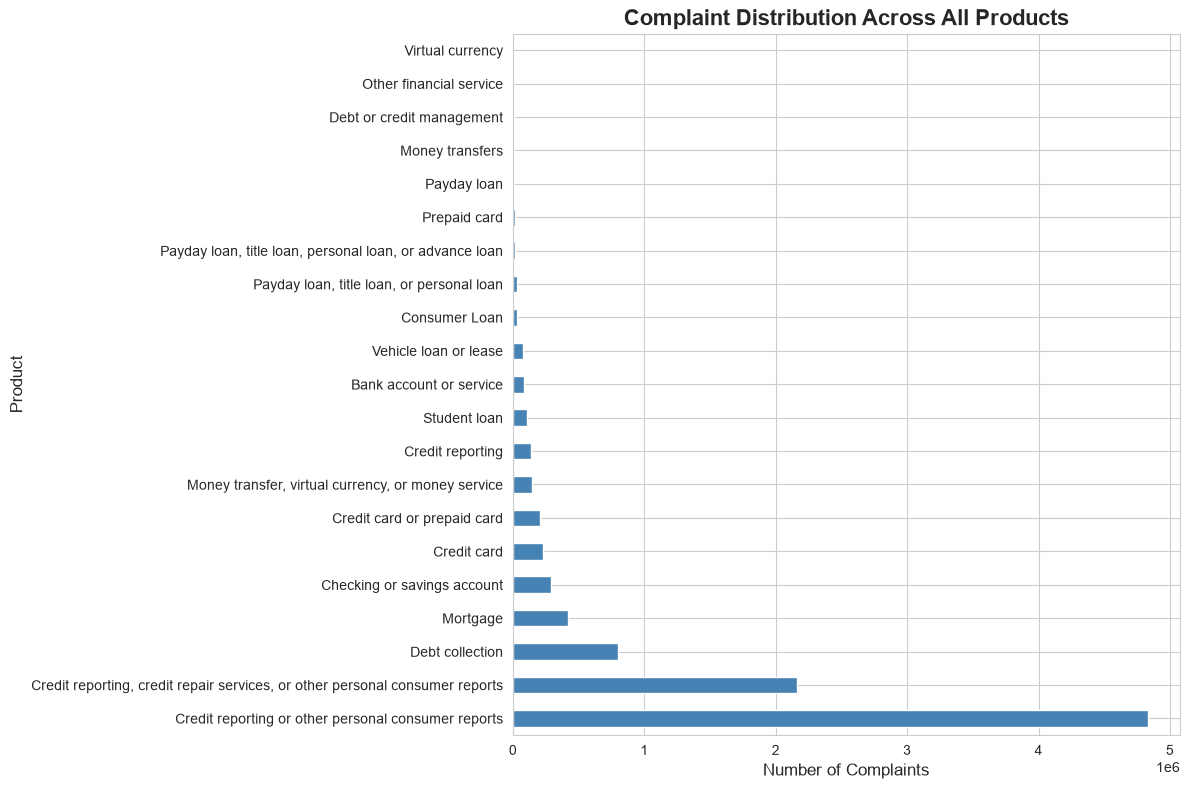

Chart saved!


In [9]:
plt.figure(figsize=(12, 8))

product_counts.plot(
    kind='barh',
    color='steelblue',
    edgecolor='white'
)

plt.title('Complaint Distribution Across All Products', fontsize=16, fontweight='bold')
plt.xlabel('Number of Complaints', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/product_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

#### Narrative length Analysis

In [10]:
df_with_narrative = df[df['Consumer complaint narrative'].notna()].copy()

print(f"Complaints WITH narrative: {len(df_with_narrative):,}")
print(f"Complaints WITHOUT narrative: {df['Consumer complaint narrative'].isna().sum():,}")
print(f"Percentage with narrative: {len(df_with_narrative)/len(df)*100:.1f}%")

df_with_narrative['word_count'] = df_with_narrative['Consumer complaint narrative'].apply(
    lambda x: len(str(x).split())
)

print("\nNarrative length statistics (word count):")
print(df_with_narrative['word_count'].describe())

Complaints WITH narrative: 2,980,756
Complaints WITHOUT narrative: 6,629,041
Percentage with narrative: 31.0%

Narrative length statistics (word count):
count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: word_count, dtype: float64


### visualizing narrative length

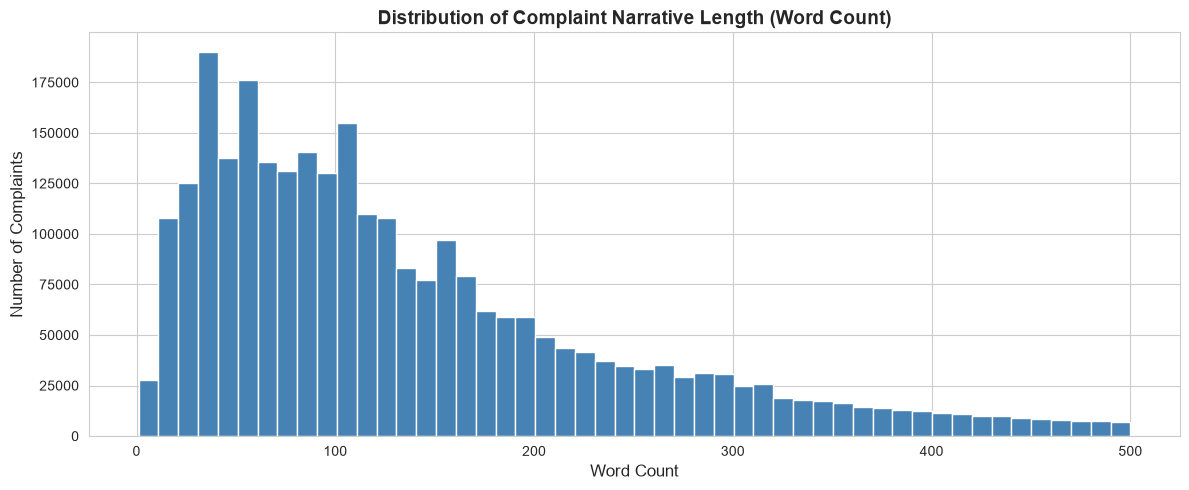

Very short narratives (under 10 words): 21,938
Very long narratives (over 1000 words): 32,428


In [11]:
plt.figure(figsize=(12, 5))

df_with_narrative[df_with_narrative['word_count'] <= 500]['word_count'].hist(
    bins=50,
    color='steelblue',
    edgecolor='white'
)

plt.title('Distribution of Complaint Narrative Length (Word Count)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.tight_layout()
plt.savefig('../data/processed/narrative_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Flag very short and very long narratives
very_short = df_with_narrative[df_with_narrative['word_count'] < 10]
very_long = df_with_narrative[df_with_narrative['word_count'] > 1000]

print(f"Very short narratives (under 10 words): {len(very_short):,}")
print(f"Very long narratives (over 1000 words): {len(very_long):,}")

### Filter Dataset

In [12]:
product_mapping = {
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Checking or savings account': 'Savings Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
    'Payday loan, title loan, or personal loan': 'Personal Loan',
    'Consumer Loan': 'Personal Loan',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal Loan',
    'Payday loan': 'Personal Loan'
}

df_filtered = df[df['Product'].isin(product_mapping.keys())].copy()

df_filtered['product_category'] = df_filtered['Product'].map(product_mapping)

print(f"Rows after product filter: {len(df_filtered):,}")
print(f"\nStandardized product categories:")
print(df_filtered['product_category'].value_counts())

Rows after product filter: 958,923

Standardized product categories:
product_category
Credit Card        433055
Savings Account    291178
Money Transfer     150420
Personal Loan       84270
Name: count, dtype: int64


#### Remove empty narratives

In [13]:
df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].notna()
].copy()

df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].str.strip() != ''
].copy()

print(f"Rows after removing empty narratives: {len(df_filtered):,}")
print(f"\nFinal complaint count per product:")
print(df_filtered['product_category'].value_counts())

Rows after removing empty narratives: 465,679

Final complaint count per product:
product_category
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       37341
Name: count, dtype: int64


### Clean Text Narratives

Understanding what needs cleaning

In [14]:
print("SAMPLE RAW NARRATIVES BEFORE CLEANING \n")

for i, narrative in enumerate(df_filtered['Consumer complaint narrative'].head(5)):
    print(f"--- Narrative {i+1} ---")
    print(narrative[:500])  
    print()

SAMPLE RAW NARRATIVES BEFORE CLEANING 

--- Narrative 1 ---
A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However, they have failed to remove this from the three credit agencies and this fraud is now impacting my credit score based on a hard credit pull done by XXXX XXXX that was done by a fraudster.

--- Narrative 2 ---
I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outside their branch. 

I went into the branch and was told they couldn't help and had to phone the customer service for help. I did this and was told I was helped gave all the info for the time terminal id aact # s, XXXX was able to find the transaction and give me this info, he said the dispute would take a few days. 

I waited a f

### The cleaning function

In [17]:
def clean_narrative(text):
   
    text = str(text)
    if text.startswith("b'") or text.startswith('b"'):
        text = text[2:-1]  
    
    
    text = text.lower()
    
   
    boilerplate_patterns = [
        r'i am writing to file a complaint.*?\.',
        r'to whom it may concern.*?\.',
        r'i am writing to complain.*?\.',
        r'dear cfpb.*?\,',
        r'dear consumer financial protection bureau.*?\.',
        r'i would like to file a complaint.*?\.',
        r'this is a complaint.*?\.',
        r'xxxx',
        r'xx/xx/xxxx',   
    ]
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, ' ', text, flags=re.IGNORECASE)
    
    
    text = re.sub(r'\{\$[\d,]+\.?\d*\}', ' ', text)
    
    
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    
    text = re.sub(r'\b\d{1,3}\b', ' ', text)
    
    
    text = re.sub(r'\s+', ' ', text)
    
   
    text = text.strip()
    
    return text

In [18]:
print("Cleaning narratives")

df_filtered['cleaned_narrative'] = df_filtered['Consumer complaint narrative'].apply(
    clean_narrative
)

print(f"Done! Cleaned {len(df_filtered):,} narratives")

print("\n BEFORE vs AFTER CLEANING \n")
for i in range(3):
    print(f"--- Example {i+1} ---")
    print(f"BEFORE: {df_filtered['Consumer complaint narrative'].iloc[i][:300]}")
    print(f"AFTER:  {df_filtered['cleaned_narrative'].iloc[i][:300]}")
    print()

Cleaning narratives
Done! Cleaned 465,679 narratives

 BEFORE vs AFTER CLEANING 

--- Example 1 ---
BEFORE: A XXXX XXXX card was opened under my name by a fraudster. I received a notice from XXXX  that an account was just opened under my name. I reached out to XXXX XXXX to state that this activity was unauthorized and not me. XXXX XXXX confirmed this was fraudulent and immediately closed the card. However
AFTER:  a card was opened under my name by a fraudster i received a notice from that an account was just opened under my name i reached out to to state that this activity was unauthorized and not me confirmed this was fraudulent and immediately closed the card however they have failed to remove this from th

--- Example 2 ---
BEFORE: I made the mistake of using my wellsfargo debit card to depsit funds Into XXXXXXXX ATM machine outside their branch. 

I went into the branch and was told they couldn't help and had to phone the customer service for help. I did this and was told I was hel

In [19]:
df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].notna()
].copy()

df_filtered = df_filtered[
    df_filtered['Consumer complaint narrative'].str.strip() != ''
].copy()

print(f"Rows after removing empty narratives: {len(df_filtered):,}")
print(f"\nFinal complaint count per product:")
print(df_filtered['product_category'].value_counts())

Rows after removing empty narratives: 465,679

Final complaint count per product:
product_category
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       37341
Name: count, dtype: int64


Saving the processed Data

In [20]:
final_columns = [
    'Complaint ID',
    'product_category',
    'Product',
    'Issue',
    'Sub-issue',
    'Company',
    'State',
    'Date received',
    'Consumer complaint narrative',
    'cleaned_narrative'
]

df_final = df_filtered[final_columns].copy()

df_final.columns = [
    'complaint_id',
    'product_category',
    'product',
    'issue',
    'sub_issue',
    'company',
    'state',
    'date_received',
    'original_narrative',
    'cleaned_narrative'
]

print(f"Final dataset shape: {df_final.shape}")
print(f"\nColumn names:")
print(df_final.columns.tolist())
print(f"\nSample of final data:")
df_final.head(3)

Final dataset shape: (465679, 10)

Column names:
['complaint_id', 'product_category', 'product', 'issue', 'sub_issue', 'company', 'state', 'date_received', 'original_narrative', 'cleaned_narrative']

Sample of final data:


,complaint_id,product_category,product,issue,sub_issue,company,state,date_received,original_narrative,cleaned_narrative
12237,14069121,Credit Card,Credit card,Getting a credit card,Card opened without my consent or knowledge,"CITIBANK, N.A.",TX,2025-06-13,A XXXX XXXX card was opened under my name by a...,a card was opened under my name by a fraudster...
12532,14061897,Savings Account,Checking or savings account,Managing an account,Deposits and withdrawals,WELLS FARGO & COMPANY,ID,2025-06-13,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,14047085,Credit Card,Credit card,"Other features, terms, or problems",Other problem,"CITIBANK, N.A.",NY,2025-06-12,"Dear CFPB, I have a secured credit card with c...",i have a secured credit card with citibank whi...


### save to CSV

In [21]:
OUTPUT_PATH = os.path.join(BASE_DIR, "data", "processed", "filtered_complaints.csv")

df_final.to_csv(OUTPUT_PATH, index=False)


file_size = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)  
print(f"File saved successfully!")
print(f"Location: {OUTPUT_PATH}")
print(f"File size: {file_size:.1f} MB")
print(f"Total rows saved: {len(df_final):,}")
print(f"Total columns saved: {len(df_final.columns)}")

File saved successfully!
Location: c:\Users\HP\Desktop\Week-7\data\processed\filtered_complaints.csv
File size: 1040.0 MB
Total rows saved: 465,679
Total columns saved: 10


### Final Summary statistics

In [22]:
print("TASK 1 COMPLETE — FINAL SUMMARY")


print(f"\nOriginal dataset:        9,609,797 complaints")
print(f"After product filter:    {958923:,} complaints")
print(f"After removing empties:  {len(df_final):,} complaints")
print(f"\nFinal breakdown by product:")
print(df_final['product_category'].value_counts())

print(f"\nNarrative word count stats:")
df_final['word_count'] = df_final['cleaned_narrative'].apply(
    lambda x: len(str(x).split())
)
print(df_final['word_count'].describe().round(1))

print(f"\nOutput saved to: data/processed/filtered_complaints.csv")

TASK 1 COMPLETE — FINAL SUMMARY

Original dataset:        9,609,797 complaints
After product filter:    958,923 complaints
After removing empties:  465,679 complaints

Final breakdown by product:
product_category
Credit Card        189334
Savings Account    140319
Money Transfer      98685
Personal Loan       37341
Name: count, dtype: int64

Narrative word count stats:
count    465679.0
mean        194.2
std         212.6
min           0.0
25%          78.0
50%         130.0
75%         242.0
max        6238.0
Name: word_count, dtype: float64

Output saved to: data/processed/filtered_complaints.csv


## 7. Summary & Key Findings

### Finding 1 — Dataset Scale
The raw CFPB dataset contains 9,609,797 complaints across 21 product categories.
After filtering to the 4 target products (Credit Card, Savings Account, 
Money Transfer, Personal Loan), 958,923 complaints remained.
Removing entries with no consumer narrative reduced this to 465,679 
— the final working dataset.

### Finding 2 — Narrative Quality
Only 31% of all complaints contained written narratives. 
Average narrative length is 175 words (std=226), with a range of 1 to 6,469 words.
21,938 narratives were under 10 words and 32,428 exceeded 1,000 words, 
indicating high variation in complaint detail.

### Finding 3 — Product Distribution
Credit Card complaints dominate at 40.7% (189,334), followed by 
Savings Account at 30.1% (140,319), Money Transfer at 21.2% (98,685), 
and Personal Loan at 8.0% (37,341). This imbalance should be 
considered during RAG evaluation.